Part 1: Learning Curves

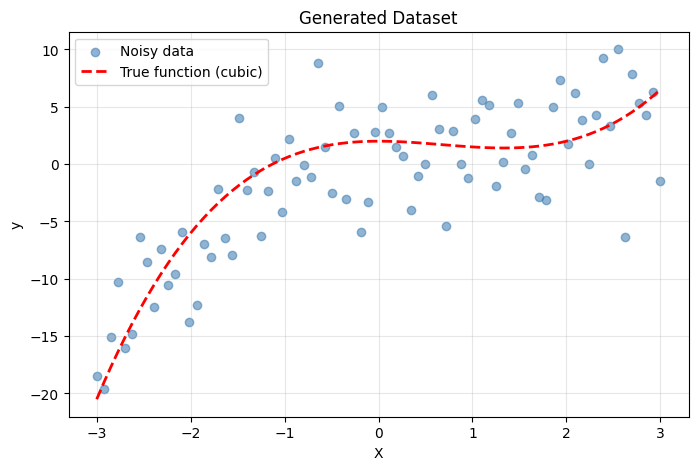

Dataset created: 80 points


In [1]:
# ─────────────────────────────────────────────────────────
# BLOCK 1: Imports and generate the dataset
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)   # reproducibility

# ── Generate data from a known TRUE function ──
# True relationship: y = 0.5x³ - x² + 2  (a cubic curve)
# We add random noise to make it realistic.
n = 80
X = np.linspace(-3, 3, n)                       # 80 points from -3 to 3
y_true = 0.5*X**3 - X**2 + 2                    # the real underlying curve
y = y_true + np.random.normal(0, 4, n)          # add noise (std=4)

# Quick look at the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='steelblue', label='Noisy data')
plt.plot(X, y_true, 'r--', linewidth=2, label='True function (cubic)')
plt.xlabel('X'); plt.ylabel('y')
plt.title('Generated Dataset')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print("Dataset created:", n, "points")

In [2]:
# ─────────────────────────────────────────────────────────
# BLOCK 2: Split into 70% training, 30% validation
# ─────────────────────────────────────────────────────────

# Shuffle the indices randomly, then take the first 70% for training
indices = np.random.permutation(n)
split = int(0.7 * n)

train_idx = indices[:split]
val_idx   = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples  : 56
Validation samples: 24


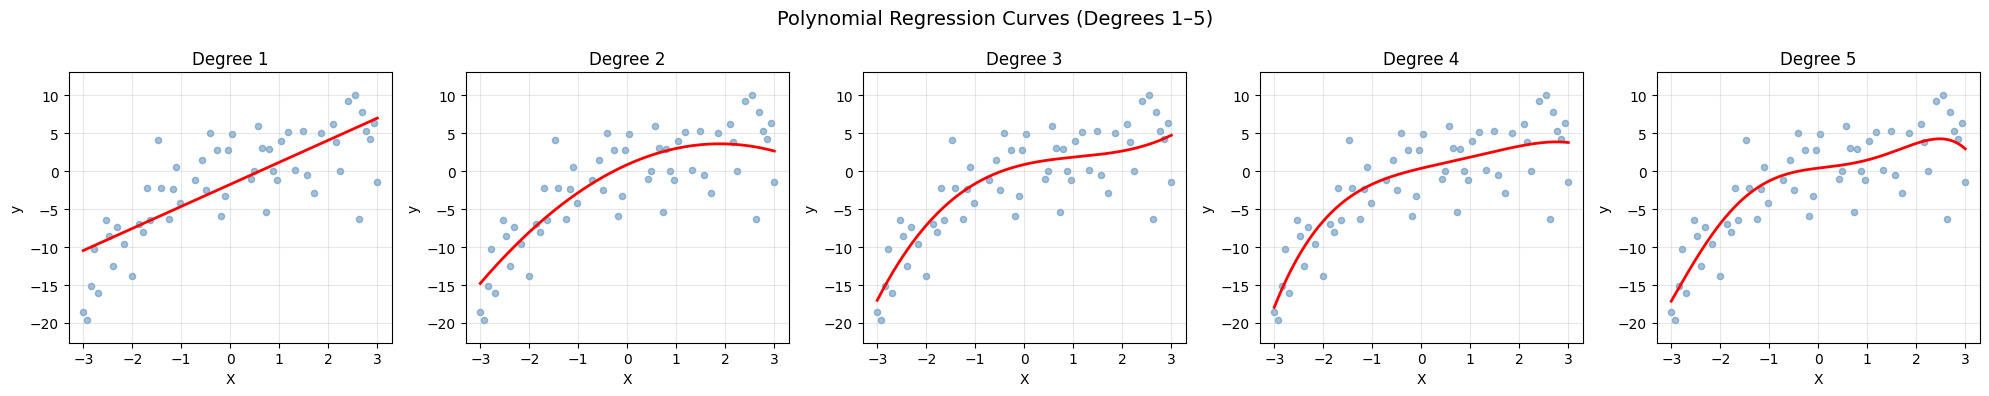

In [3]:
# ─────────────────────────────────────────────────────────
# BLOCK 3: Fit polynomial models for degrees 1 to 5
# ─────────────────────────────────────────────────────────

degrees = [1, 2, 3, 4, 5]

# Create a smooth x range for drawing the fitted curve
x_smooth = np.linspace(X.min(), X.max(), 200)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, d in zip(axes, degrees):
    # np.polyfit finds best polynomial coefficients of degree d
    coefs = np.polyfit(X_train, y_train, d)

    # np.polyval evaluates that polynomial at our smooth x values
    y_curve = np.polyval(coefs, x_smooth)

    # Plot training data + fitted curve
    ax.scatter(X_train, y_train, alpha=0.5, color='steelblue', s=20)
    ax.plot(x_smooth, y_curve, color='red', linewidth=2)
    ax.set_title(f'Degree {d}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.set_ylim(y.min()-3, y.max()+3)   # same y-scale for comparison
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Regression Curves (Degrees 1–5)', fontsize=14)
plt.tight_layout()
plt.show()

# What you see:
# Degree 1 = straight line (too simple, misses the curve = UNDERFIT)
# Degree 3 = matches the true cubic shape well (GOOD FIT)
# Degree 5 = starts wiggling to chase noise (beginning to OVERFIT)

Degree 1: Train MSE =  20.08  |  Val MSE =  18.89
Degree 2: Train MSE =  14.93  |  Val MSE =  14.00
Degree 3: Train MSE =  13.83  |  Val MSE =  12.15
Degree 4: Train MSE =  13.65  |  Val MSE =  12.81
Degree 5: Train MSE =  13.52  |  Val MSE =  12.19


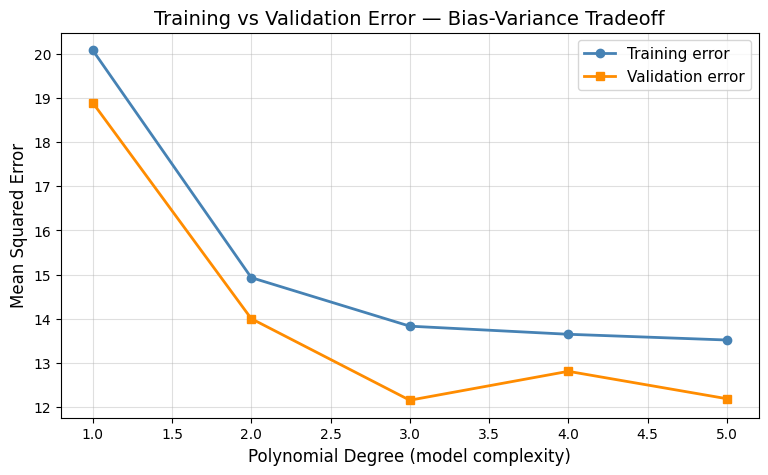

In [5]:
# ─────────────────────────────────────────────────────────
# BLOCK 4: Compute Train & Validation error for each degree
# ─────────────────────────────────────────────────────────

train_errors = []
val_errors   = []

for d in degrees:
    coefs = np.polyfit(X_train, y_train, d)

    # Mean Squared Error on training data
    train_pred = np.polyval(coefs, X_train)
    train_mse  = np.mean((train_pred - y_train)**2)

    # Mean Squared Error on validation data
    val_pred = np.polyval(coefs, X_val)
    val_mse  = np.mean((val_pred - y_val)**2)

    train_errors.append(train_mse)
    val_errors.append(val_mse)

    print(f"Degree {d}: Train MSE = {train_mse:6.2f}  |  Val MSE = {val_mse:6.2f}")

# ── Plot error vs degree ──
plt.figure(figsize=(9, 5))
plt.plot(degrees, train_errors, 'o-', color='steelblue', linewidth=2, label='Training error')
plt.plot(degrees, val_errors,   's-', color='darkorange', linewidth=2, label='Validation error')
plt.xlabel('Polynomial Degree (model complexity)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Training vs Validation Error — Bias-Variance Tradeoff', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.show()

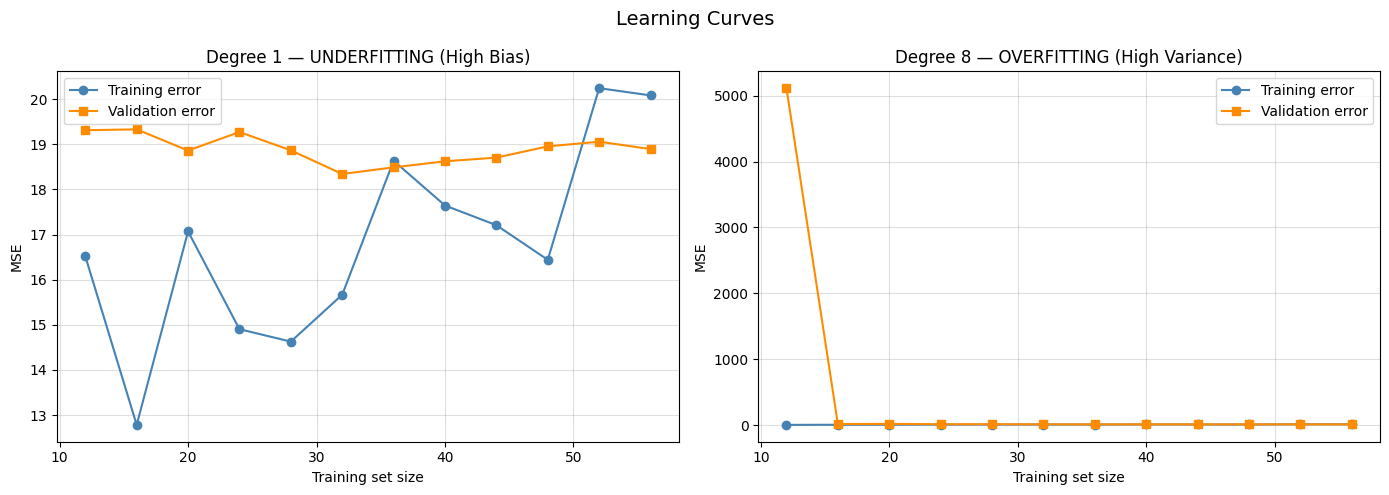

In [6]:
# ─────────────────────────────────────────────────────────
# BLOCK 5: Learning Curves — error vs training set size
# ─────────────────────────────────────────────────────────

def learning_curve(degree, X_tr, y_tr, X_va, y_va, min_size=12):
    """For increasing training set sizes, record train and val error."""
    sizes, tr_errs, va_errs = [], [], []

    # Try training sizes from min_size up to the full training set
    for size in range(min_size, len(X_tr) + 1, 4):
        # Train on just the first 'size' samples
        coefs = np.polyfit(X_tr[:size], y_tr[:size], degree)

        tr_mse = np.mean((np.polyval(coefs, X_tr[:size]) - y_tr[:size])**2)
        va_mse = np.mean((np.polyval(coefs, X_va) - y_va)**2)

        sizes.append(size); tr_errs.append(tr_mse); va_errs.append(va_mse)

    return sizes, tr_errs, va_errs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Simple model (degree 1 = underfitting) ──
s1, tr1, va1 = learning_curve(1, X_train, y_train, X_val, y_val)
axes[0].plot(s1, tr1, 'o-', color='steelblue', label='Training error')
axes[0].plot(s1, va1, 's-', color='darkorange', label='Validation error')
axes[0].set_title('Degree 1 — UNDERFITTING (High Bias)')
axes[0].set_xlabel('Training set size'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# ── Right: Complex model (degree 8 = overfitting) ──
s2, tr2, va2 = learning_curve(8, X_train, y_train, X_val, y_val)
axes[1].plot(s2, tr2, 'o-', color='steelblue', label='Training error')
axes[1].plot(s2, va2, 's-', color='darkorange', label='Validation error')
axes[1].set_title('Degree 8 — OVERFITTING (High Variance)')
axes[1].set_xlabel('Training set size'); axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Learning Curves', fontsize=14)
plt.tight_layout()
plt.show()

Part 2: Regularization

In [7]:
# ─────────────────────────────────────────────────────────
# BLOCK 6: Ridge Regression using Gradient Descent
# ─────────────────────────────────────────────────────────

# ── Helper: build polynomial features ──
def make_poly_features(x, degree):
    """Turn a 1D x into columns [x, x², x³, ..., x^degree]."""
    return np.column_stack([x**i for i in range(1, degree + 1)])

DEGREE = 5

# Build features for full dataset
X_poly = make_poly_features(X, DEGREE)

# ── Standardize features (CRITICAL) ──
# Powers like x⁵ can be huge. Without scaling, gradient descent
# and the penalty term behave very badly. We scale to mean=0, std=1.
feat_mean = X_poly.mean(axis=0)
feat_std  = X_poly.std(axis=0)
X_poly_scaled = (X_poly - feat_mean) / feat_std

# Add bias column (column of 1s)
X_design = np.column_stack([np.ones(len(X)), X_poly_scaled])

# Center y so the bias term behaves nicely
y_mean = y.mean()
y_centered = y - y_mean


def ridge_gradient_descent(X, y, lam, lr=0.01, iters=3000):
    """
    Ridge = Linear regression + L2 penalty (sum of SQUARED weights).

    Loss = (1/m)·Σ(error²)  +  λ·Σ(wⱼ²)

    The penalty discourages large weights, which keeps the curve smooth.
    Note: we do NOT penalize the bias term (w[0]).
    """
    m, p = X.shape
    w = np.zeros(p)

    for _ in range(iters):
        # Standard MSE gradient
        grad = (1/m) * (X.T @ (X @ w - y))

        # L2 regularization gradient = λ·w  (but not for bias)
        reg = lam * w
        reg[0] = 0          # don't regularize bias

        w = w - lr * (grad + reg)

    return w

# ── Train Ridge for each λ ──
lambdas = [0, 0.01, 0.1, 1, 10]
ridge_weights = {}

print("RIDGE REGRESSION RESULTS")
print("-" * 55)
for lam in lambdas:
    w = ridge_gradient_descent(X_design, y_centered, lam)
    ridge_weights[lam] = w

    train_loss = np.mean((X_design @ w - y_centered)**2)
    weight_norm = np.linalg.norm(w[1:])   # size of weights (excluding bias)

    print(f"λ = {lam:5}:  train loss = {train_loss:6.3f}  |  "
          f"||w|| = {weight_norm:.3f}")
    print(f"          weights = {w[1:].round(3)}")

RIDGE REGRESSION RESULTS
-------------------------------------------------------
λ =     0:  train loss = 13.280  |  ||w|| = 4.032
          weights = [ 2.587 -1.544  2.579 -0.731  0.03 ]
λ =  0.01:  train loss = 13.297  |  ||w|| = 3.927
          weights = [ 2.566 -1.493  2.447 -0.77   0.168]
λ =   0.1:  train loss = 13.468  |  ||w|| = 3.479
          weights = [ 2.334 -1.247  1.907 -0.917  0.792]
λ =     1:  train loss = 16.086  |  ||w|| = 2.472
          weights = [ 1.43  -0.776  1.317 -0.73   1.094]
λ =    10:  train loss = 32.884  |  ||w|| = 0.710
          weights = [ 0.392 -0.189  0.391 -0.184  0.358]


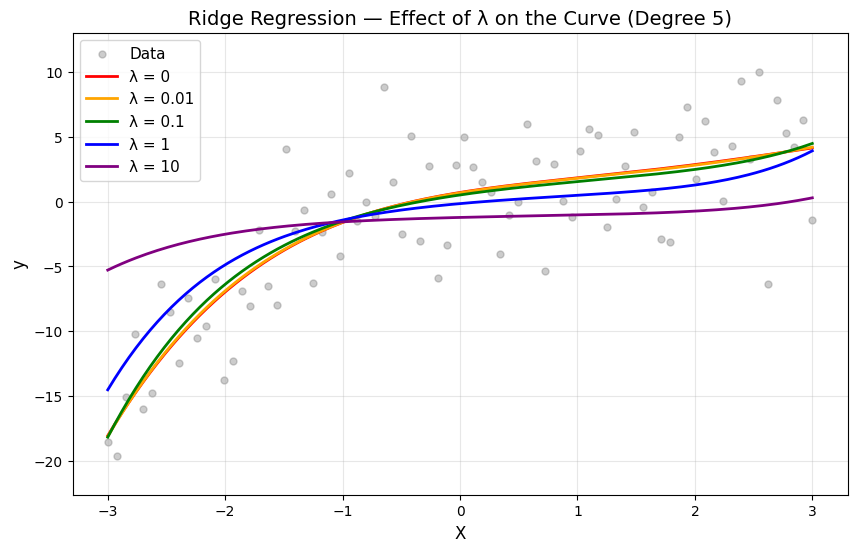

In [8]:
# ─────────────────────────────────────────────────────────
# BLOCK 7: Plot Ridge curves for each λ
# ─────────────────────────────────────────────────────────

# Smooth x for drawing curves — must apply SAME scaling as training
x_smooth = np.linspace(X.min(), X.max(), 200)
x_smooth_poly = make_poly_features(x_smooth, DEGREE)
x_smooth_scaled = (x_smooth_poly - feat_mean) / feat_std
x_smooth_design = np.column_stack([np.ones(len(x_smooth)), x_smooth_scaled])

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.4, color='gray', label='Data', s=25)

colors = ['red', 'orange', 'green', 'blue', 'purple']
for lam, color in zip(lambdas, colors):
    w = ridge_weights[lam]
    # Predict and add back the y_mean we subtracted earlier
    y_curve = x_smooth_design @ w + y_mean
    plt.plot(x_smooth, y_curve, color=color, linewidth=2, label=f'λ = {lam}')

plt.xlabel('X', fontsize=12); plt.ylabel('y', fontsize=12)
plt.title('Ridge Regression — Effect of λ on the Curve (Degree 5)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(y.min()-3, y.max()+3)
plt.show()

# λ=0    → no penalty, wiggly curve (overfits)
# λ=10   → strong penalty, very flat curve (underfits)
# middle → smooth, well-fitted curve

In [9]:
# ─────────────────────────────────────────────────────────
# BLOCK 8: Lasso Regression + compare with Ridge
# ─────────────────────────────────────────────────────────

def lasso_gradient_descent(X, y, lam, lr=0.01, iters=3000):
    """
    Lasso = Linear regression + L1 penalty (sum of ABSOLUTE weights).

    Loss = (1/m)·Σ(error²)  +  λ·Σ|wⱼ|

    Key difference from Ridge: the L1 penalty drives some weights
    to EXACTLY ZERO, effectively removing useless features.
    The gradient of |w| is sign(w) (+1 if positive, -1 if negative).
    """
    m, p = X.shape
    w = np.zeros(p)

    for _ in range(iters):
        grad = (1/m) * (X.T @ (X @ w - y))

        # L1 regularization gradient = λ·sign(w)  (not for bias)
        reg = lam * np.sign(w)
        reg[0] = 0

        w = w - lr * (grad + reg)

    return w

print("LASSO vs RIDGE COMPARISON")
print("=" * 70)
print(f"{'λ':>6} | {'Ridge ||w||':>11} | {'Lasso ||w||':>11} | {'Lasso #nonzero':>14}")
print("-" * 70)

for lam in lambdas:
    w_ridge = ridge_weights[lam]
    w_lasso = lasso_gradient_descent(X_design, y_centered, lam)

    ridge_norm = np.linalg.norm(w_ridge[1:])
    lasso_norm = np.linalg.norm(w_lasso[1:])
    # Count weights that are effectively non-zero
    lasso_nonzero = np.sum(np.abs(w_lasso[1:]) > 0.01)

    print(f"{lam:>6} | {ridge_norm:>11.3f} | {lasso_norm:>11.3f} | {lasso_nonzero:>14}")

print("""
HOW λ AFFECTS THE MODEL:
─────────────────────────────────────────────────────────────
- MODEL COMPLEXITY:
  Larger λ → simpler model. The penalty forces weights down, so
  the curve becomes flatter and less wiggly. λ=0 = most complex.

- PARAMETER MAGNITUDE:
  As λ increases, ||w|| shrinks. Ridge shrinks ALL weights
  smoothly toward zero. Lasso shrinks them AND sets some to
  EXACTLY zero (feature selection).

- OVERFITTING BEHAVIOUR:
  λ=0    → overfitting (model chases noise)
  λ small→ good balance (smooth fit)
  λ large→ underfitting (too constrained)

RIDGE vs LASSO:
  Ridge (L2): keeps all features but shrinks them. Best when many
              features are useful.
  Lasso (L1): zeroes out weak features → sparse model. Best for
              feature selection when only a few features matter.
─────────────────────────────────────────────────────────────
""")

LASSO vs RIDGE COMPARISON
     λ | Ridge ||w|| | Lasso ||w|| | Lasso #nonzero
----------------------------------------------------------------------
     0 |       4.032 |       4.032 |              5
  0.01 |       3.927 |       4.027 |              5
   0.1 |       3.479 |       3.962 |              4
     1 |       2.472 |       3.133 |              5
    10 |       0.710 |       0.139 |              4

HOW λ AFFECTS THE MODEL:
─────────────────────────────────────────────────────────────
- MODEL COMPLEXITY:
  Larger λ → simpler model. The penalty forces weights down, so
  the curve becomes flatter and less wiggly. λ=0 = most complex.

- PARAMETER MAGNITUDE:
  As λ increases, ||w|| shrinks. Ridge shrinks ALL weights
  smoothly toward zero. Lasso shrinks them AND sets some to
  EXACTLY zero (feature selection).

- OVERFITTING BEHAVIOUR:
  λ=0    → overfitting (model chases noise)
  λ small→ good balance (smooth fit)
  λ large→ underfitting (too constrained)

RIDGE vs LASSO:
  Ridge (

In [10]:
# ─────────────────────────────────────────────────────────
# BLOCK 9: 5-Fold Cross-Validation to find best λ
# ─────────────────────────────────────────────────────────

# First, make a proper train/test split (80/20)
all_idx = np.random.permutation(n)
n_train = int(0.8 * n)
train_full_idx = all_idx[:n_train]
test_idx       = all_idx[n_train:]

X_train_full, y_train_full = X[train_full_idx], y[train_full_idx]
X_test,       y_test       = X[test_idx],       y[test_idx]

# λ values to test (on a log scale)
lambdas_cv = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

K = 5
fold_size = len(X_train_full) // K

cv_errors = []   # average validation error for each λ

print("5-FOLD CROSS-VALIDATION")
print("-" * 40)

for lam in lambdas_cv:
    fold_errors = []

    for fold in range(K):
        # ── Pick this fold as validation, rest as training ──
        v_start = fold * fold_size
        v_end   = (fold + 1) * fold_size

        val_mask = np.zeros(len(X_train_full), dtype=bool)
        val_mask[v_start:v_end] = True

        X_v, y_v = X_train_full[val_mask],  y_train_full[val_mask]
        X_t, y_t = X_train_full[~val_mask], y_train_full[~val_mask]

        # ── Build features + standardize using the TRAIN fold only ──
        Xt_poly = make_poly_features(X_t, DEGREE)
        Xv_poly = make_poly_features(X_v, DEGREE)
        m_, s_  = Xt_poly.mean(0), Xt_poly.std(0)
        Xt_s = (Xt_poly - m_) / s_
        Xv_s = (Xv_poly - m_) / s_
        Xt_d = np.column_stack([np.ones(len(X_t)), Xt_s])
        Xv_d = np.column_stack([np.ones(len(X_v)), Xv_s])

        ym_ = y_t.mean()

        # Train Ridge on the train fold
        w = ridge_gradient_descent(Xt_d, y_t - ym_, lam)

        # Validate on the held-out fold
        val_err = np.mean((Xv_d @ w + ym_ - y_v)**2)
        fold_errors.append(val_err)

    avg_error = np.mean(fold_errors)
    cv_errors.append(avg_error)
    print(f"λ = {lam:8}:  avg validation error = {avg_error:.3f}")

# Pick the λ with lowest CV error
best_lambda = lambdas_cv[np.argmin(cv_errors)]
print(f"\nBest λ (lowest CV error) = {best_lambda}")

5-FOLD CROSS-VALIDATION
----------------------------------------
λ =   0.0001:  avg validation error = 18.039
λ =    0.001:  avg validation error = 18.036
λ =     0.01:  avg validation error = 18.012
λ =      0.1:  avg validation error = 17.959
λ =        1:  avg validation error = 20.039
λ =       10:  avg validation error = 36.435

Best λ (lowest CV error) = 0.1


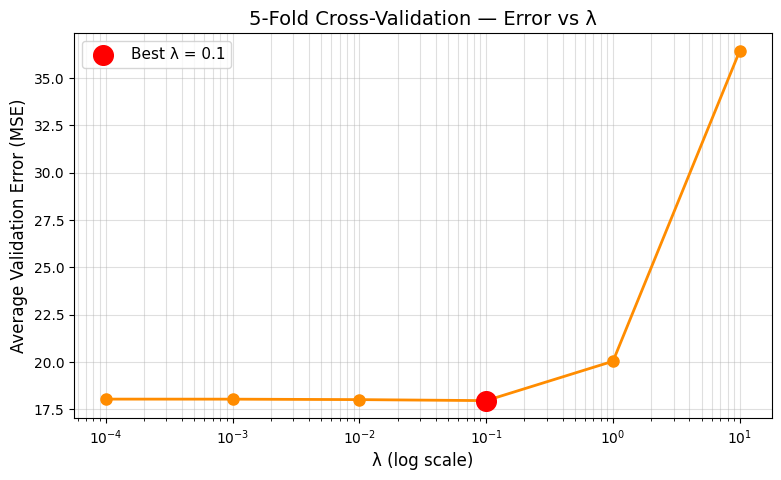


Final model trained with best λ = 0.1
TEST SET ERROR (MSE) = 7.898

This is an honest estimate of how the model performs on
completely unseen data — the goal of the whole pipeline.


In [11]:
# ─────────────────────────────────────────────────────────
# BLOCK 10: Plot CV error vs λ, retrain, evaluate on test
# ─────────────────────────────────────────────────────────

# ── Plot validation error vs λ (log scale on x-axis) ──
plt.figure(figsize=(9, 5))
plt.semilogx(lambdas_cv, cv_errors, 'o-', color='darkorange', linewidth=2, markersize=8)
plt.scatter([best_lambda], [min(cv_errors)], color='red', s=200, zorder=5,
            label=f'Best λ = {best_lambda}')
plt.xlabel('λ (log scale)', fontsize=12)
plt.ylabel('Average Validation Error (MSE)', fontsize=12)
plt.title('5-Fold Cross-Validation — Error vs λ', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, which='both')
plt.show()

# ── Retrain on the FULL training set using best λ ──
Xtr_poly = make_poly_features(X_train_full, DEGREE)
m_f, s_f = Xtr_poly.mean(0), Xtr_poly.std(0)
Xtr_s = (Xtr_poly - m_f) / s_f
Xtr_d = np.column_stack([np.ones(len(X_train_full)), Xtr_s])
ym_f  = y_train_full.mean()

final_w = ridge_gradient_descent(Xtr_d, y_train_full - ym_f, best_lambda)

# ── Evaluate on the TEST set ──
Xte_poly = make_poly_features(X_test, DEGREE)
Xte_s = (Xte_poly - m_f) / s_f       # use TRAIN scaling
Xte_d = np.column_stack([np.ones(len(X_test)), Xte_s])

test_pred = Xte_d @ final_w + ym_f
test_error = np.mean((test_pred - y_test)**2)

print(f"\nFinal model trained with best λ = {best_lambda}")
print(f"TEST SET ERROR (MSE) = {test_error:.3f}")
print("\nThis is an honest estimate of how the model performs on")
print("completely unseen data — the goal of the whole pipeline.")